In [1]:
import numpy as np
import verde as vd
import boule as bl
import matplotlib.pyplot as plt
import harmonica as hm

d:\conda_envs\planet\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def bipolar_surface_2(lat, lon):

    f = 0.15

    relief = 10e3*np.sin(1.5*f*lon)*np.cos(f*lat)

    return relief

#region = (20, 60, 0, 40)
region=(-40, 40, 20, 60)
grid_lon,grid_lat = vd.grid_coordinates(region=region, shape=(41, 41))

lon_o=np.sort(np.unique(grid_lon))
lat_o=np.sort(np.unique(grid_lat))

lon=0.5*(lon_o[:-1] + lon_o[1:])
lat=0.5*(lat_o[:-1] + lat_o[1:])
LON, LAT = np.meshgrid(lon, lat)
shape = np.shape(LON)

reference = -35e3*np.ones(shape)
height_obs = 40e3         # 11 km
density_contrast = 600     # kg/m^3

#surface=bipolar_surface(LON,LAT)
surface=bipolar_surface_2(LAT,LON)

(20.5, 59.5)

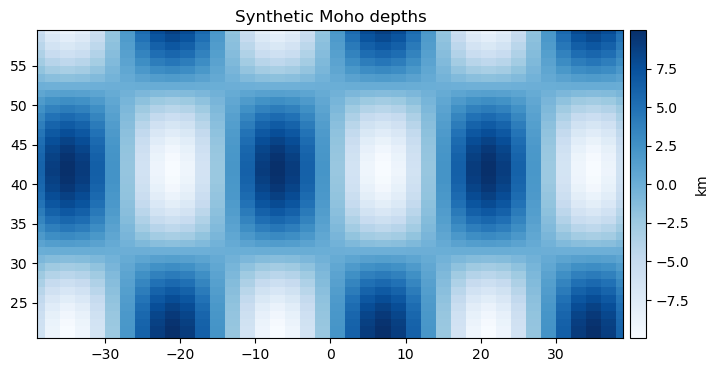

In [3]:
plt.figure(figsize=(9, 4))
plt.title("Synthetic Moho depths")
plt.pcolormesh(LON, LAT, -0.001*surface, 
               cmap='Blues')
plt.colorbar(pad=0.01).set_label('km')
plt.xlim(LON.min(), LON.max())
plt.ylim(LAT.min(), LAT.max())

In [4]:
bl.Moon2015.mean_radius*np.ones_like(LAT)+surface

array([[1743187.68642397, 1746042.31509546, 1747126.63140365, ...,
        1727175.36859635, 1728259.68490454, 1731114.31357603],
       [1743180.06387638, 1746031.08799707, 1747114.03513481, ...,
        1727187.96486519, 1728270.91200293, 1731121.93612362],
       [1743037.04155203, 1745820.4332666 , 1746877.69057588, ...,
        1727424.30942412, 1728481.5667334 , 1731264.95844797],
       ...,
       [1741367.10623999, 1743360.81883485, 1744118.12051196, ...,
        1730183.87948804, 1730941.18116515, 1732934.89376001],
       [1741968.19649972, 1744246.15269596, 1745111.42287195, ...,
        1729190.57712805, 1730055.84730404, 1732333.80350028],
       [1742461.10291132, 1744972.14472377, 1745925.95129588, ...,
        1728376.04870412, 1729329.85527623, 1731840.89708868]],
      shape=(40, 40))

In [5]:
lon=np.sort(np.unique(LON))
lat=np.sort(np.unique(LAT))

density_array=density_contrast*np.ones_like(LAT)
density_array = density_array.copy()
mask = surface <= 0
density_array[mask] = -np.abs(density_array[mask])
tess_layer=hm.tesseroid_layer((lon,lat),
                              surface=bl.Moon2015.mean_radius*np.ones_like(LAT)+reference+surface,
                              reference=bl.Moon2015.mean_radius*np.ones_like(LAT)+reference,
                              properties={"density":density_array})
coordinates=(LON,LAT,bl.Moon2015.mean_radius*np.ones_like(LAT)+height_obs)
g=tess_layer.tesseroid_layer.gravity(coordinates, field="g_z",progressbar=False)

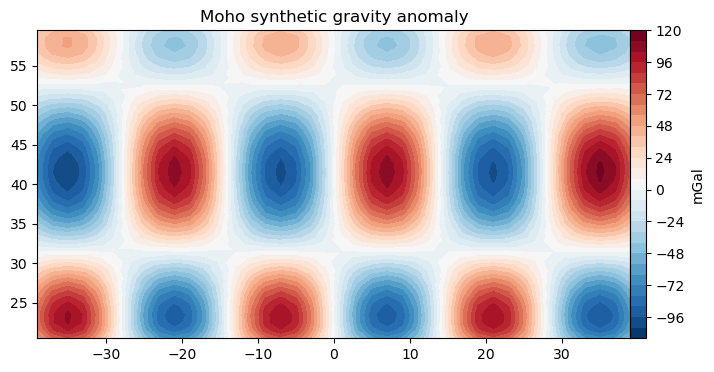

In [7]:
plt.figure(figsize=(9, 4))
plt.title('Moho synthetic gravity anomaly')
plt.tricontourf(LON.ravel(), LAT.ravel(), g.ravel(),30, cmap='RdBu_r')
plt.colorbar(pad=0).set_label('mGal')